In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("placement_data.csv")
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [3]:
df.shape

(10000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [5]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe(include='all')

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,NaN,NaN,NotPlaced
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5854,7318,NaN,NaN,5803
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,NaN,NaN,69.159400,74.501500,NaN
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,NaN,NaN,10.430459,8.919527,NaN
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,NaN,NaN,55.000000,57.000000,NaN
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,NaN,NaN,59.000000,67.000000,NaN
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,NaN,NaN,70.000000,73.000000,NaN
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,NaN,NaN,78.000000,83.000000,NaN


In [8]:
df['PlacementStatus'].value_counts(normalize=True)

PlacementStatus
NotPlaced    0.5803
Placed       0.4197
Name: proportion, dtype: float64

In [9]:
df = df.drop(columns=['StudentID'])

In [10]:
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].map({'Yes': 1, 'No': 0})
df['PlacementTraining'] = df['PlacementTraining'].map({'Yes': 1, 'No': 0})

In [11]:
df['PlacementStatus'] = df['PlacementStatus'].map({'Placed': 1, 'NotPlaced': 0})

In [12]:
df.dtypes
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,0
1,8.9,0,3,2,90,4.0,1,1,78,82,1
2,7.3,1,2,2,82,4.8,1,0,79,80,0
3,7.5,1,1,2,85,4.4,1,1,81,80,1
4,8.3,1,2,2,86,4.5,1,1,74,88,1


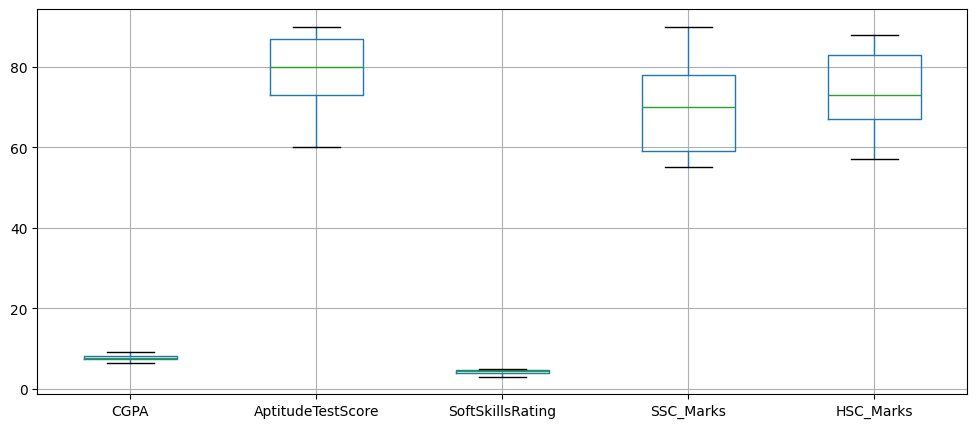

In [13]:
df.boxplot(column=['CGPA','AptitudeTestScore','SoftSkillsRating','SSC_Marks','HSC_Marks'], figsize=(12,5))
plt.show()

In [14]:
print(df[['CGPA','AptitudeTestScore','SSC_Marks','HSC_Marks']].agg(['min','max']))

     CGPA  AptitudeTestScore  SSC_Marks  HSC_Marks
min   6.5                 60         55         57
max   9.1                 90         90         88


In [15]:
# Checking correlation with the target
df.corr()['PlacementStatus'].sort_values(ascending=False).round(2)

PlacementStatus              1.00
AptitudeTestScore            0.52
HSC_Marks                    0.51
ExtracurricularActivities    0.48
Projects                     0.48
SSC_Marks                    0.47
SoftSkillsRating             0.43
CGPA                         0.42
Workshops/Certifications     0.36
PlacementTraining            0.32
Internships                  0.26
Name: PlacementStatus, dtype: float64

In [16]:
df.groupby('PlacementTraining')['PlacementStatus'].mean()

PlacementTraining
0    0.155854
1    0.516398
Name: PlacementStatus, dtype: float64

In [17]:
df.groupby('ExtracurricularActivities')['PlacementStatus'].mean()

ExtracurricularActivities
0    0.136758
1    0.620089
Name: PlacementStatus, dtype: float64

In [18]:
# Model Training
from sklearn.model_selection import train_test_split
X=df.drop(columns=['PlacementStatus'])
y=df['PlacementStatus']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(8000, 10) (2000, 10)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score

lor_model=LogisticRegression(max_iter=1000,class_weight='balanced')
lor_model.fit(X_train,y_train)
lor_pred=lor_model.predict(X_test)
lor_prob=lor_model.predict_proba(X_test)[:,1]

print("Classification Report:\n",classification_report(y_test, lor_pred))
print("ROC-AUC:", roc_auc_score(y_test, lor_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.78      0.82      1161
           1       0.73      0.82      0.77       839

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.80      0.80      2000

ROC-AUC: 0.8837455688912296


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=200,max_depth=8,class_weight='balanced',random_state=42)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)
rf_prob=rf_model.predict_proba(X_test)[:,1]

print("Classification Report:\n",classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82      1161
           1       0.74      0.80      0.77       839

    accuracy                           0.80      2000
   macro avg       0.79      0.80      0.79      2000
weighted avg       0.80      0.80      0.80      2000

ROC-AUC: 0.8825208222331044


In [21]:
import pickle
pickle.dump(lor_model,open("D:/Data Science Course/placement-predictor/backend/model.pkl", "wb"))

Background dataset has 8000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8000 when initializing the masker.


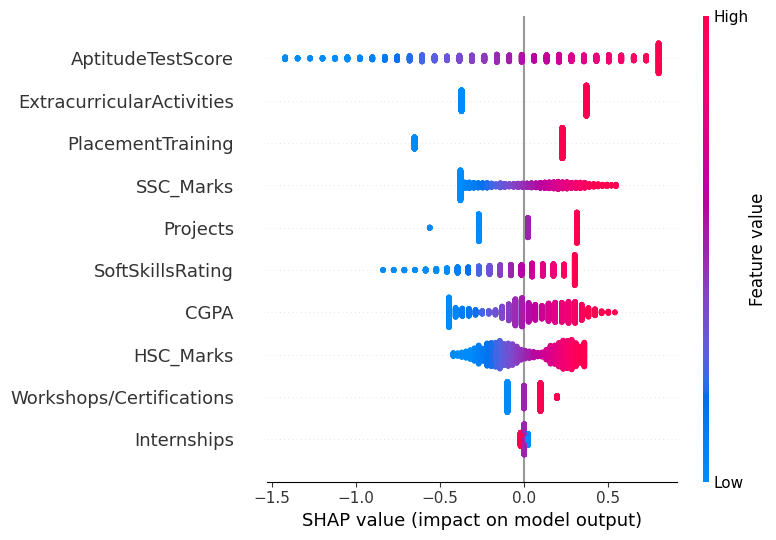

In [22]:
import shap
explainer=shap.LinearExplainer(lor_model,X_train)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test,show=False)
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show() 

In [24]:
background = X_train.mean().values.reshape(1, -1)
pickle.dump(background, open("D:/Data Science Course/placement-predictor/backend/background.pkl", "wb"))